In [2]:
# ============================================
# CROP RECOMMENDATION SYSTEM
# Phase 3 — Dataset Collection & Understanding
# ============================================

In [1]:
# Test that all libraries are working
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("scikit-learn version:", sklearn.__version__)
print("All systems go! ✅")

pandas version: 3.0.2
numpy version: 2.4.4
scikit-learn version: 1.8.0
All systems go! ✅


In [3]:
# Import the libraries we need for this phase
import pandas as pd      # for loading and working with our dataset
import numpy as np       # for numerical operations

# -------------------------------------------
# Load the dataset from the data/ folder
# -------------------------------------------
# pd.read_csv() reads a CSV file and converts it
# into a DataFrame — pandas' version of a table
df = pd.read_csv('../data/crop_data.csv')

# Confirm it loaded successfully
print("Dataset loaded successfully!")
print("Shape:", df.shape)   # (rows, columns)

Dataset loaded successfully!
Shape: (2200, 8)


In [4]:
# -------------------------------------------
# .head() shows the FIRST 5 rows by default
# This gives us a quick peek at what the data looks like
# -------------------------------------------
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
# -------------------------------------------
# .tail() shows the LAST 5 rows
# Useful to check if data ends cleanly
# -------------------------------------------
print("=== LAST 5 ROWS ===")
df.tail()

=== LAST 5 ROWS ===


,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [6]:
# -------------------------------------------
# .info() gives a full summary of the dataset:
# - Column names
# - How many non-null (non-missing) values exist
# - Data type of each column
# -------------------------------------------
print("=== DATASET INFO ===")
df.info()

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [ ]:
# -------------------------------------------
# .columns shows all column names in the dataset
# -------------------------------------------
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

# -------------------------------------------
# .dtypes shows the data type of each column
# -------------------------------------------
print("\n=== DATA TYPES ===")
print(df.dtypes)

In [1]:
# ============================================
# CROP RECOMMENDATION SYSTEM
# Phase 4 — Data Preprocessing
# ============================================

# Import libraries
import pandas as pd      # data manipulation
import numpy as np       # numerical operations

# Load the dataset again (always reload at start of new phase)
df = pd.read_csv('../data/crop_data.csv')

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (2200, 8)


In [2]:
# -------------------------------------------
# .isnull() checks every cell for missing values
# .sum() counts how many are missing per column
# -------------------------------------------
print("=== MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing)

print("\n=== TOTAL MISSING VALUES ===")
print(missing.sum())

# -------------------------------------------
# Show percentage of missing values per column
# Helps decide how serious the problem is
# -------------------------------------------
print("\n=== MISSING VALUE PERCENTAGE ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

=== MISSING VALUES PER COLUMN ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== TOTAL MISSING VALUES ===
0

=== MISSING VALUE PERCENTAGE ===
N              0.0
P              0.0
K              0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64


In [3]:
# -------------------------------------------
# .duplicated() marks every duplicate row as True
# .sum() counts how many duplicates exist
# -------------------------------------------
print("=== NUMBER OF DUPLICATE ROWS ===")
duplicates = df.duplicated().sum()
print(duplicates)

# -------------------------------------------
# Show the actual duplicate rows if any exist
# -------------------------------------------
print("\n=== DUPLICATE ROWS (if any) ===")
print(df[df.duplicated()])

=== NUMBER OF DUPLICATE ROWS ===
0

=== DUPLICATE ROWS (if any) ===
Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


In [4]:
# -------------------------------------------
# Check that all feature columns are numbers
# and label column is text (object)
# -------------------------------------------
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== SHAPE CONFIRMATION ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

=== DATA TYPES ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

=== SHAPE CONFIRMATION ===
Rows: 2200
Columns: 8


In [5]:
# -------------------------------------------
# X = all columns EXCEPT the label column
# These are our 7 input features
# df.drop() removes the 'label' column
# axis=1 means we're dropping a COLUMN (not a row)
# -------------------------------------------
X = df.drop('label', axis=1)

# -------------------------------------------
# y = ONLY the label column
# This is what our model will predict
# -------------------------------------------
y = df['label']

# Confirm the separation worked correctly
print("=== FEATURES (X) ===")
print("Shape:", X.shape)
print("Columns:", X.columns.tolist())

print("\n=== TARGET (y) ===")
print("Shape:", y.shape)
print("First 5 values:", y.head().tolist())

=== FEATURES (X) ===
Shape: (2200, 7)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

=== TARGET (y) ===
Shape: (2200,)
First 5 values: ['rice', 'rice', 'rice', 'rice', 'rice']


In [6]:
# -------------------------------------------
# Import train_test_split from scikit-learn
# This function automatically splits our data
# -------------------------------------------
from sklearn.model_selection import train_test_split

# -------------------------------------------
# Split the data:
# test_size=0.2    → 20% goes to testing, 80% to training
# random_state=42  → fixes the random split so we get
#                    the same split every time we run
#                    (makes results reproducible)
# stratify=y       → ensures all 22 crops are represented
#                    proportionally in both train and test sets
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,              # input features
    y,              # target labels
    test_size=0.2,  # 20% for testing
    random_state=42,# reproducible split
    stratify=y      # balanced crop distribution
)

# -------------------------------------------
# Confirm the split worked correctly
# -------------------------------------------
print("=== TRAIN/TEST SPLIT RESULTS ===")
print(f"Total samples       : {len(X)}")
print(f"Training samples    : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples     : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

print("\n=== SHAPES ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

=== TRAIN/TEST SPLIT RESULTS ===
Total samples       : 2200
Training samples    : 1760 (80%)
Testing samples     : 440 (20%)

=== SHAPES ===
X_train shape: (1760, 7)
X_test shape : (440, 7)
y_train shape: (1760,)
y_test shape : (440,)


In [7]:
# -------------------------------------------
# Check crop distribution in training set
# Each crop should have ~80 samples (80% of 100)
# -------------------------------------------
print("=== CROP DISTRIBUTION IN TRAINING SET ===")
print(y_train.value_counts().sort_index())

print("\n=== CROP DISTRIBUTION IN TESTING SET ===")
# Each crop should have ~20 samples (20% of 100)
print(y_test.value_counts().sort_index())

=== CROP DISTRIBUTION IN TRAINING SET ===
label
apple          80
banana         80
blackgram      80
chickpea       80
coconut        80
coffee         80
cotton         80
grapes         80
jute           80
kidneybeans    80
lentil         80
maize          80
mango          80
mothbeans      80
mungbean       80
muskmelon      80
orange         80
papaya         80
pigeonpeas     80
pomegranate    80
rice           80
watermelon     80
Name: count, dtype: int64

=== CROP DISTRIBUTION IN TESTING SET ===
label
apple          20
banana         20
blackgram      20
chickpea       20
coconut        20
coffee         20
cotton         20
grapes         20
jute           20
kidneybeans    20
lentil         20
maize          20
mango          20
mothbeans      20
mungbean       20
muskmelon      20
orange         20
papaya         20
pigeonpeas     20
pomegranate    20
rice           20
watermelon     20
Name: count, dtype: int64


In [8]:
# -------------------------------------------
# Print a simple explanation of key concepts
# -------------------------------------------

concepts = {
    "Overfitting" : (
        "Model memorizes training data TOO well.\n"
        "    Works perfectly on training data.\n"
        "    Fails badly on new/test data.\n"
        "    Like a student who memorizes answers without understanding."
    ),
    "Underfitting": (
        "Model is TOO simple to learn patterns.\n"
        "    Performs poorly on BOTH training AND test data.\n"
        "    Like a student who didn't study at all."
    ),
    "Good Fit"    : (
        "Model learns patterns WITHOUT memorizing.\n"
        "    Performs well on BOTH training AND test data.\n"
        "    This is what we're aiming for!"
    )
}

print("=== MODEL FITTING CONCEPTS ===\n")
for concept, explanation in concepts.items():
    print(f"  {concept}:")
    print(f"    {explanation}\n")

=== MODEL FITTING CONCEPTS ===

  Overfitting:
    Model memorizes training data TOO well.
    Works perfectly on training data.
    Fails badly on new/test data.
    Like a student who memorizes answers without understanding.

  Underfitting:
    Model is TOO simple to learn patterns.
    Performs poorly on BOTH training AND test data.
    Like a student who didn't study at all.

  Good Fit:
    Model learns patterns WITHOUT memorizing.
    Performs well on BOTH training AND test data.
    This is what we're aiming for!



In [9]:
# ============================================
# PHASE 4 — DATA PREPROCESSING (COMPLETE)
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. Load Data ---
df = pd.read_csv('../data/crop_data.csv')

# --- 2. Check Missing Values ---
print("Missing values:", df.isnull().sum().sum())  # should be 0

# --- 3. Check Duplicates ---
print("Duplicate rows:", df.duplicated().sum())    # should be 0

# --- 4. Separate Features and Target ---
X = df.drop('label', axis=1)   # 7 input features
y = df['label']                 # crop name to predict

# --- 5. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --- 6. Final Confirmation ---
print("\n✅ Preprocessing Complete!")
print(f"   Training set : {X_train.shape[0]} samples")
print(f"   Testing set  : {X_test.shape[0]} samples")
print(f"   Features     : {X_train.columns.tolist()}")

Missing values: 0
Duplicate rows: 0

✅ Preprocessing Complete!
   Training set : 1760 samples
   Testing set  : 440 samples
   Features     : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [1]:
# ============================================
# CROP RECOMMENDATION SYSTEM
# Phase 5 — Exploratory Data Analysis (EDA)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt    # base plotting library
import seaborn as sns              # beautiful statistical plots

# --- Load data ---
df = pd.read_csv('../data/crop_data.csv')

# --- Set a clean visual style for all plots ---
sns.set_style("whitegrid")         # adds light grid to plots
plt.rcParams['figure.figsize'] = (10, 6)  # default figure size

print("Libraries loaded and dataset ready!")
print("Shape:", df.shape)

Libraries loaded and dataset ready!
Shape: (2200, 8)


C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3477739387.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


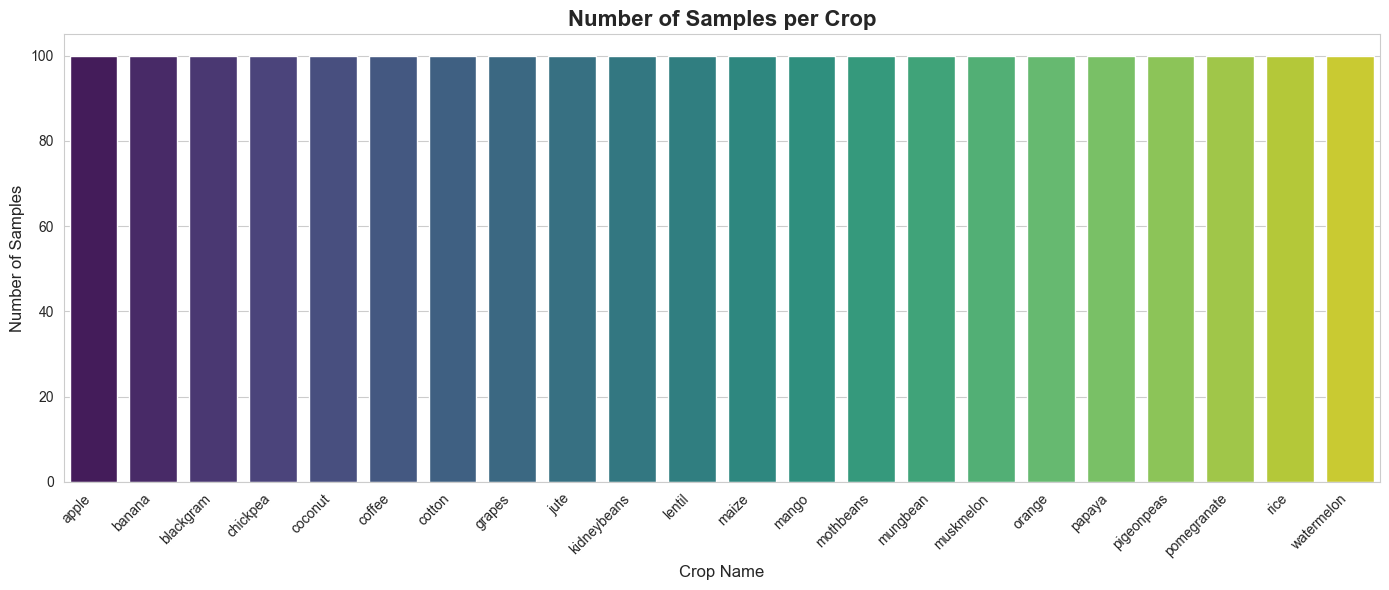

Each crop has exactly: 100 samples


In [2]:
# ============================================
# CHART 1: Crop Distribution (Bar Chart)
# ============================================

# -------------------------------------------
# Count how many samples exist for each crop
# sort by crop name alphabetically
# -------------------------------------------
crop_counts = df['label'].value_counts().sort_index()

# -------------------------------------------
# Create the bar chart
# -------------------------------------------
plt.figure(figsize=(14, 6))       # set figure width and height

# sns.barplot draws a bar for each crop
sns.barplot(
    x=crop_counts.index,          # x-axis = crop names
    y=crop_counts.values,         # y-axis = number of samples
    palette='viridis'             # color scheme
)

# --- Labels and title ---
plt.title('Number of Samples per Crop', fontsize=16, fontweight='bold')
plt.xlabel('Crop Name', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.tight_layout()                    # prevents labels from being cut off
plt.savefig('../data/chart_crop_distribution.png')  # save chart
plt.show()

print("Each crop has exactly:", crop_counts.values[0], "samples")

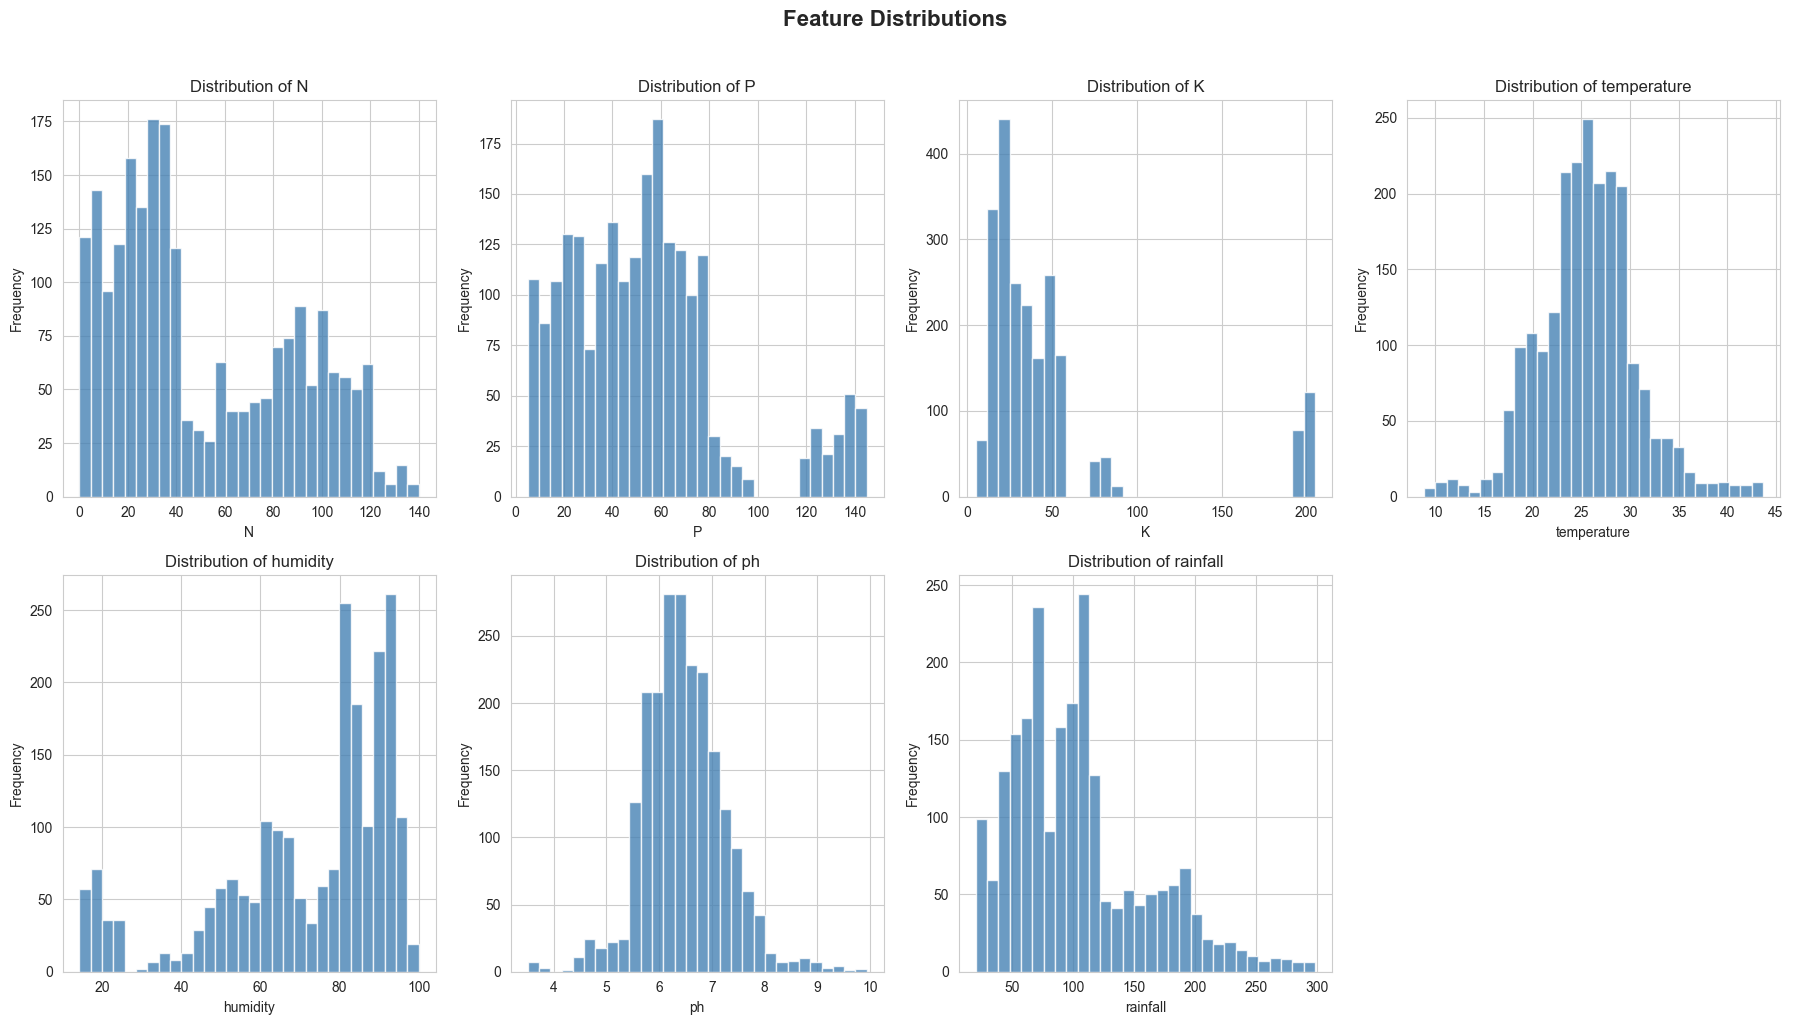

In [3]:
# ============================================
# CHART 2: Histograms for All 7 Features
# ============================================

# List of all numerical feature columns
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# -------------------------------------------
# Create a grid of 7 histograms (2 rows x 4 cols)
# figsize controls the total figure size
# -------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# -------------------------------------------
# axes.flatten() converts the 2D grid of axes
# into a 1D list so we can loop through them
# -------------------------------------------
axes = axes.flatten()

# Loop through each feature and draw its histogram
for i, feature in enumerate(features):
    axes[i].hist(
        df[feature],        # data for this feature
        bins=30,            # number of bars in histogram
        color='steelblue',  # bar color
        edgecolor='white',  # border between bars
        alpha=0.8           # slight transparency
    )
    # Add title and labels to each subplot
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# Hide the empty 8th subplot (we only have 7 features)
axes[7].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/chart_histograms.png')
plt.show()

=== CORRELATION MATRIX ===
                N     P     K  temperature  humidity    ph  rainfall
N            1.00 -0.23 -0.14         0.03      0.19  0.10      0.06
P           -0.23  1.00  0.74        -0.13     -0.12 -0.14     -0.06
K           -0.14  0.74  1.00        -0.16      0.19 -0.17     -0.05
temperature  0.03 -0.13 -0.16         1.00      0.21 -0.02     -0.03
humidity     0.19 -0.12  0.19         0.21      1.00 -0.01      0.09
ph           0.10 -0.14 -0.17        -0.02     -0.01  1.00     -0.11
rainfall     0.06 -0.06 -0.05        -0.03      0.09 -0.11      1.00


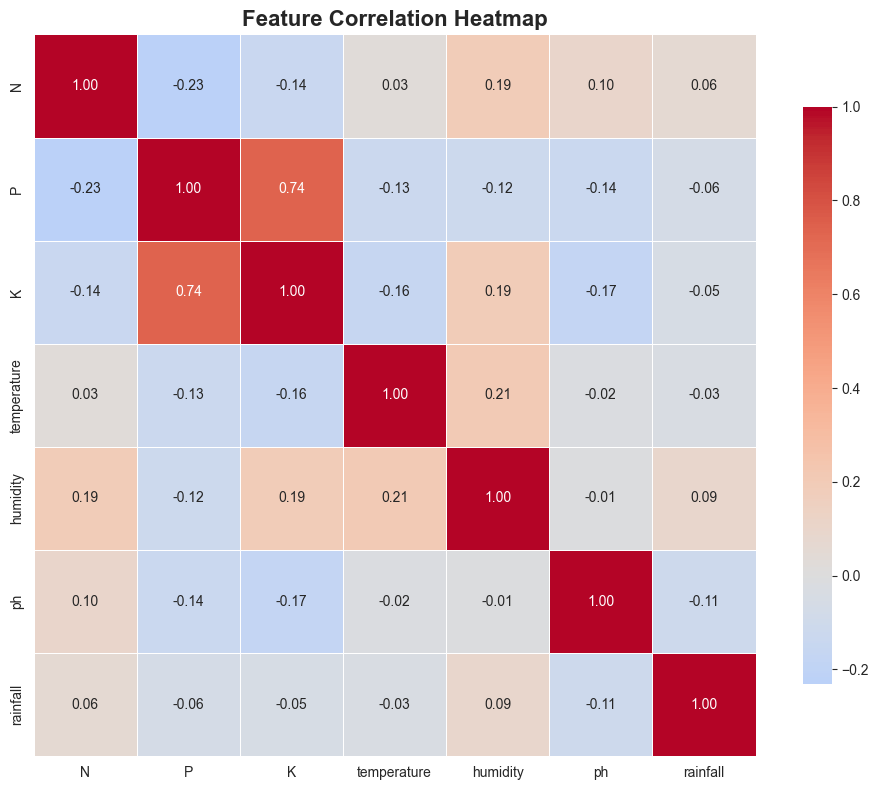

In [4]:
# ============================================
# CHART 3: Correlation Heatmap
# ============================================

# -------------------------------------------
# .corr() calculates the correlation between
# every pair of numerical columns
# Correlation ranges from -1 to +1:
#   +1 = perfect positive relationship
#    0 = no relationship
#   -1 = perfect negative relationship
# -------------------------------------------
correlation_matrix = df.drop('label', axis=1).corr()

print("=== CORRELATION MATRIX ===")
print(correlation_matrix.round(2))

# -------------------------------------------
# Draw the heatmap
# -------------------------------------------
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,           # show numbers inside each cell
    fmt='.2f',            # round numbers to 2 decimal places
    cmap='coolwarm',      # red = positive, blue = negative correlation
    center=0,             # center the color scale at 0
    square=True,          # make each cell square
    linewidths=0.5,       # add lines between cells
    cbar_kws={'shrink': 0.8}  # slightly shrink the color bar
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/chart_correlation_heatmap.png')
plt.show()

In [5]:
# ============================================
# CHART 4: Average Feature Values Per Crop
# ============================================

# -------------------------------------------
# .groupby('label') groups rows by crop name
# .mean() calculates average for each group
# .round(2) rounds to 2 decimal places
# -------------------------------------------
crop_means = df.groupby('label').mean().round(2)

print("=== AVERAGE FEATURE VALUES PER CROP ===")
print(crop_means)

=== AVERAGE FEATURE VALUES PER CROP ===
                  N       P       K  temperature  humidity    ph  rainfall
label                                                                     
apple         20.80  134.22  199.89        22.63     92.33  5.93    112.65
banana       100.23   82.01   50.05        27.38     80.36  5.98    104.63
blackgram     40.02   67.47   19.24        29.97     65.12  7.13     67.88
chickpea      40.09   67.79   79.92        18.87     16.86  7.34     80.06
coconut       21.98   16.93   30.59        27.41     94.84  5.98    175.69
coffee       101.20   28.74   29.94        25.54     58.87  6.79    158.07
cotton       117.77   46.24   19.56        23.99     79.84  6.91     80.40
grapes        23.18  132.53  200.11        23.85     81.88  6.03     69.61
jute          78.40   46.86   39.99        24.96     79.64  6.73    174.79
kidneybeans   20.75   67.54   20.05        20.12     21.61  5.75    105.92
lentil        18.77   68.36   19.41        24.51     64.80  

C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3282042872.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3282042872.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3282042872.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3282042872.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

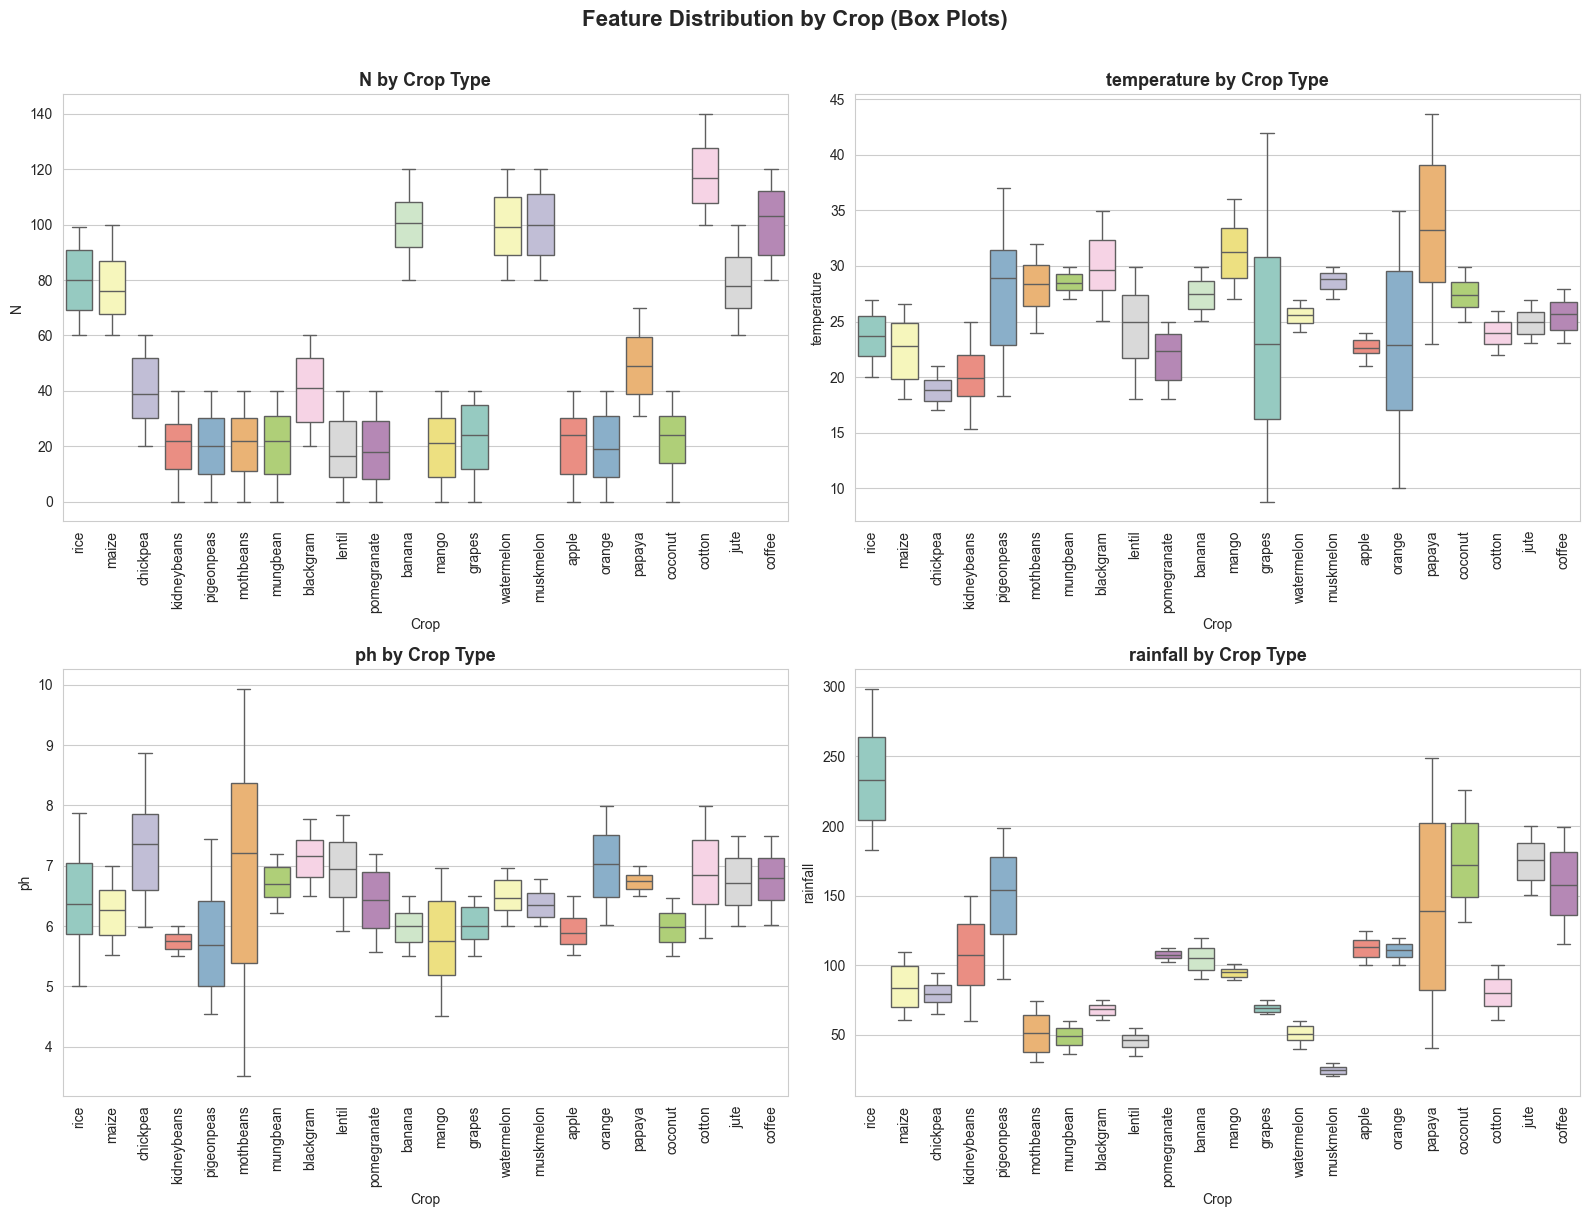

In [6]:
# ============================================
# CHART 5: Box Plots for Key Features
# ============================================

# We'll create box plots for 4 important features
key_features = ['N', 'temperature', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    # -------------------------------------------
    # sns.boxplot groups data by crop (x='label')
    # and shows distribution of the feature (y=feature)
    # -------------------------------------------
    sns.boxplot(
        data=df,
        x='label',          # group by crop name
        y=feature,          # show distribution of this feature
        palette='Set3',     # colorful palette
        ax=axes[i]          # which subplot to draw on
    )
    axes[i].set_title(f'{feature} by Crop Type', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Crop', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)  # rotate crop names vertically

plt.suptitle('Feature Distribution by Crop (Box Plots)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/chart_boxplots.png')
plt.show()

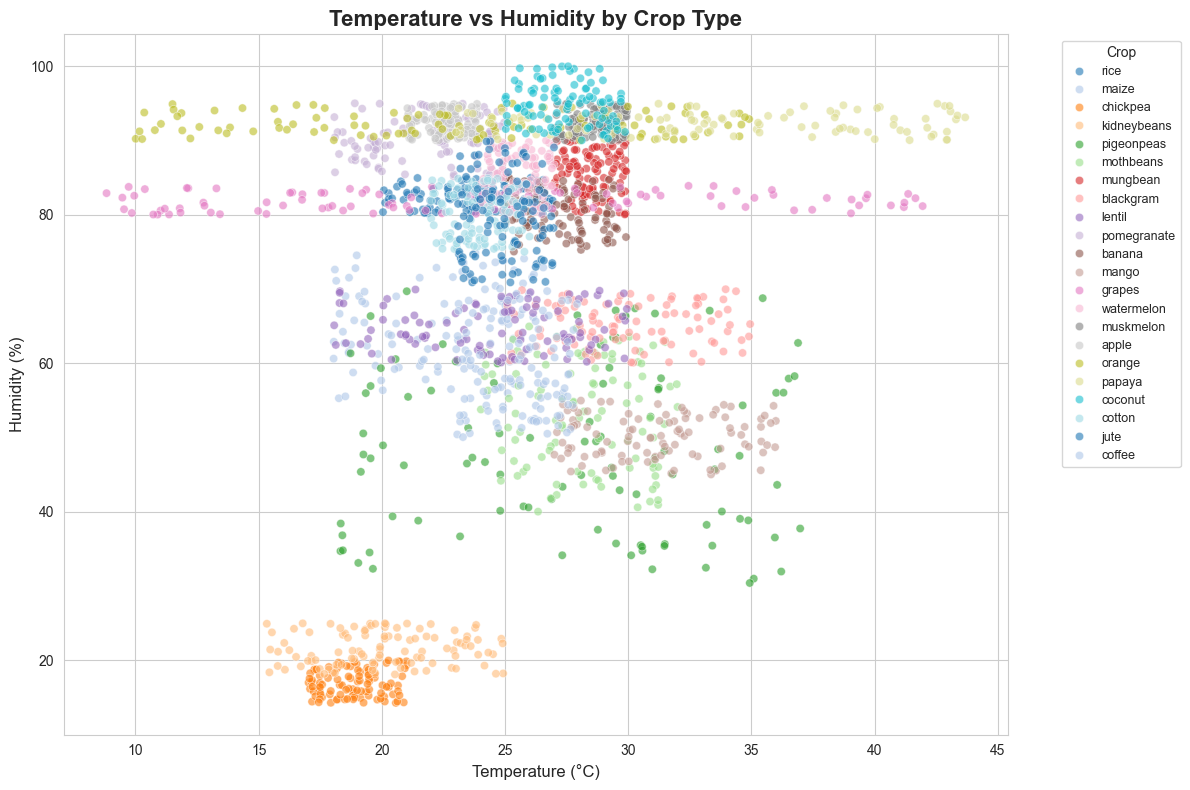

In [7]:
# ============================================
# CHART 6: Scatter Plot — Temperature vs Humidity
# ============================================

plt.figure(figsize=(12, 8))

# -------------------------------------------
# sns.scatterplot draws one dot per sample
# hue='label' colors each dot by crop type
# alpha controls dot transparency
# -------------------------------------------
sns.scatterplot(
    data=df,
    x='temperature',    # x-axis feature
    y='humidity',       # y-axis feature
    hue='label',        # color by crop name
    alpha=0.6,          # transparency so overlapping dots are visible
    palette='tab20'     # 20-color palette (we have 22 crops)
)

plt.title('Temperature vs Humidity by Crop Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Move legend outside the plot so it doesn't block data
plt.legend(
    title='Crop',
    bbox_to_anchor=(1.05, 1),  # place legend to the right
    loc='upper left',
    fontsize=9
)

plt.tight_layout()
plt.savefig('../data/chart_scatter_temp_humidity.png')
plt.show()

C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3872135753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3872135753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3872135753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\kayan\AppData\Local\Temp\ipykernel_3652\3872135753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

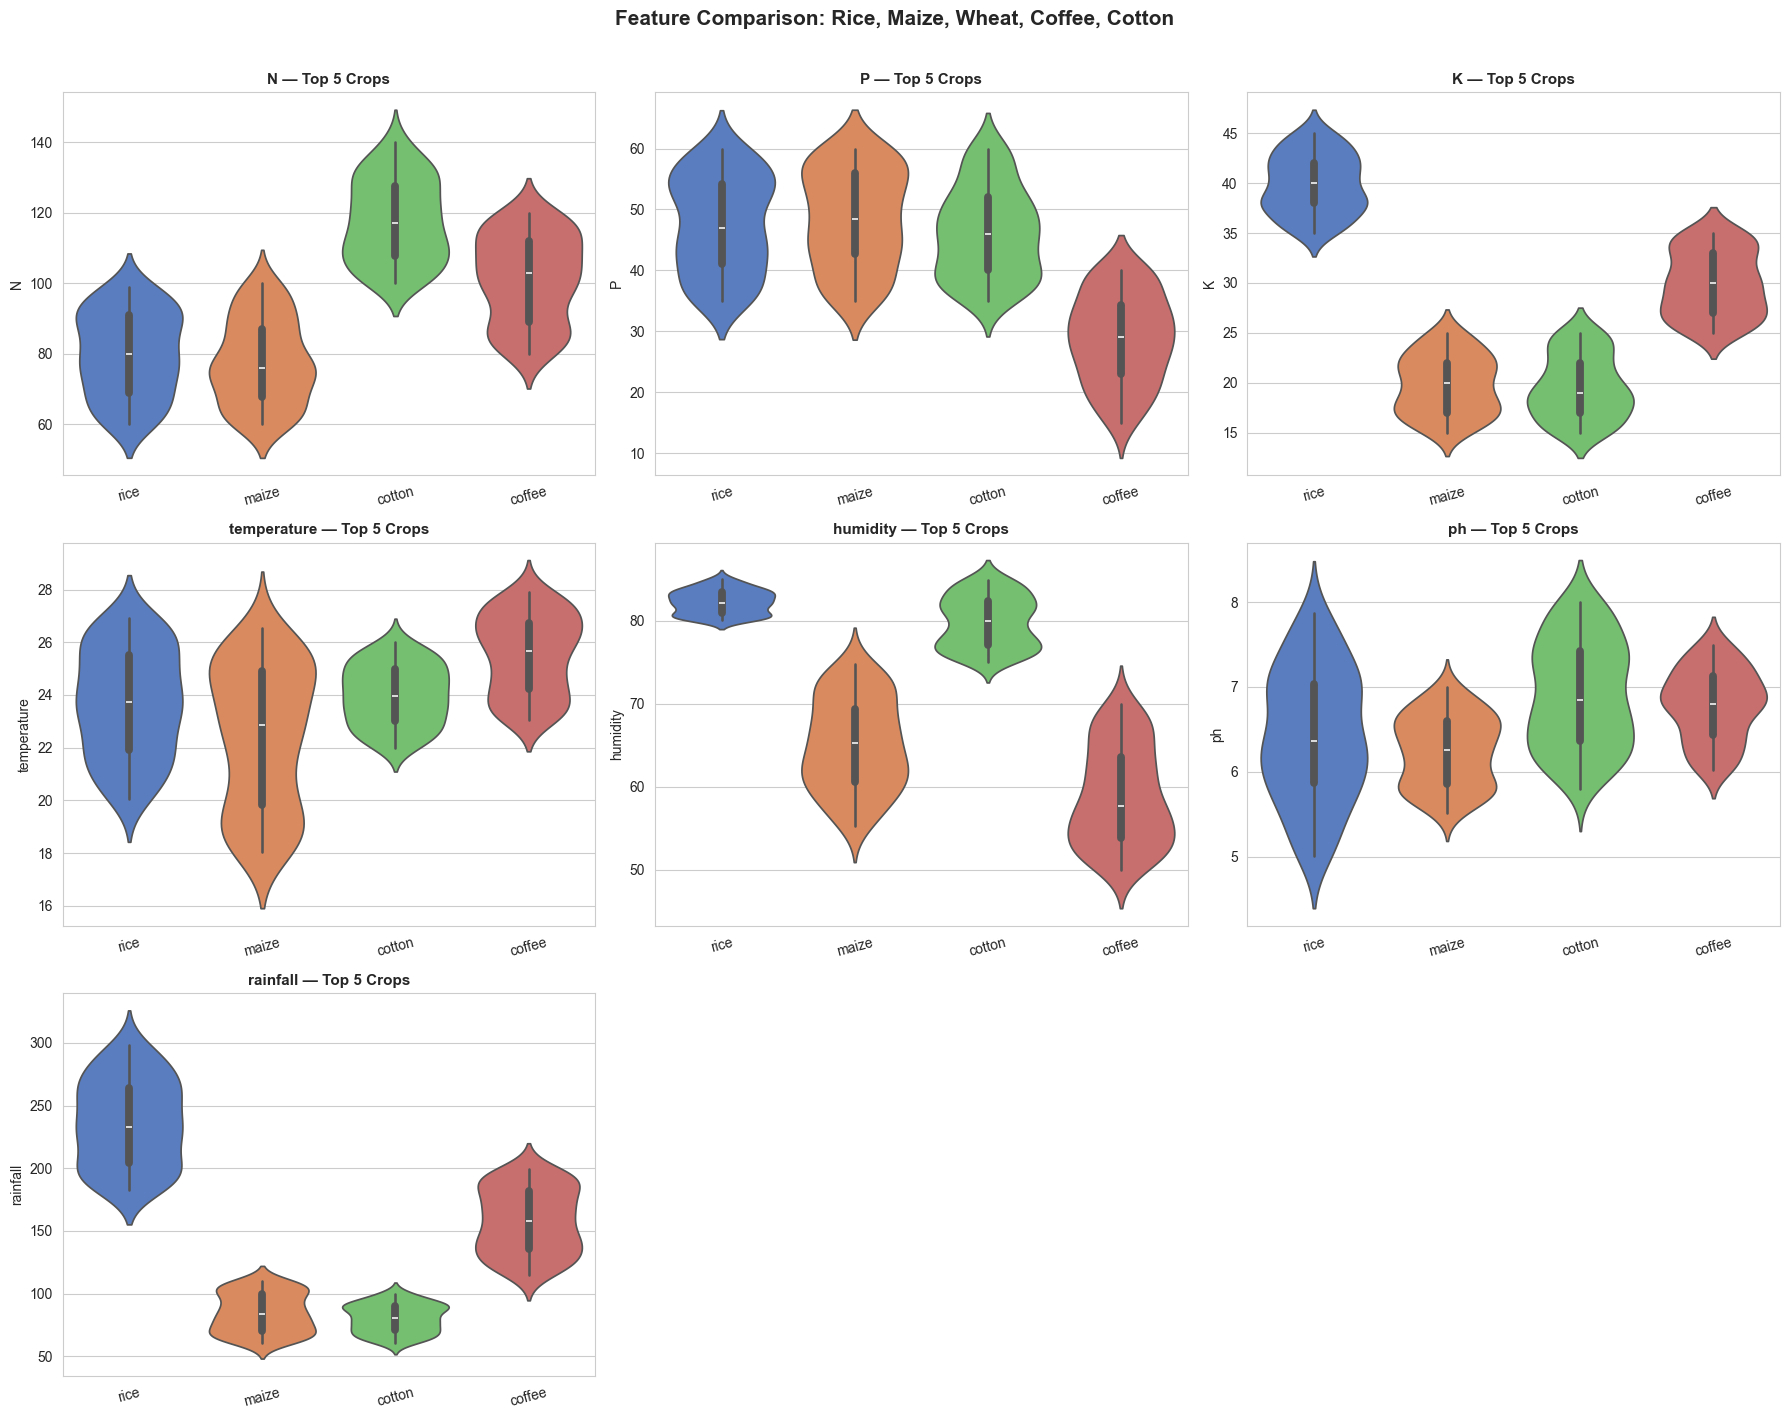

In [8]:
# ============================================
# CHART 7: Top 5 Crops Feature Comparison
# ============================================

# Select 5 interesting crops to compare
top_crops = ['rice', 'maize', 'wheat', 'coffee', 'cotton']

# Filter dataset to only include these 5 crops
df_top = df[df['label'].isin(top_crops)]

# Features to compare
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# -------------------------------------------
# Create a violin plot for each feature
# Violin plots combine box plot + distribution shape
# -------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(
        data=df_top,
        x='label',          # group by crop
        y=feature,          # feature to display
        palette='muted',    # soft color palette
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} — Top 5 Crops',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

# Hide unused subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Comparison: Rice, Maize, Wheat, Coffee, Cotton',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/chart_violin_top5.png')
plt.show()

In [10]:
# ============================================
# EDA INSIGHTS SUMMARY
# ============================================

print("=" * 55)
print("   EDA KEY INSIGHTS SUMMARY")
print("=" * 55)

insights = [
    ("Dataset Balance",
     "All 22 crops have exactly 100 samples each.\n"
     "     No bias towards any single crop."),

    ("Nitrogen (N)",
     "Varies widely (0-140).\n"
     "     High-N crops: banana, rice.\n"
     "     Low-N crops: chickpea, lentil."),

    ("Temperature",
     "Most crops grow between 20-35°C.\n"
     "     Papaya and grapes prefer higher temps.\n"
     "     Apple and grapes prefer cooler temps."),

    ("Humidity",
     "Clear split: some crops need high humidity\n"
     "     (rice, coconut) others prefer low (chickpea)."),

    ("pH",
     "Most crops prefer slightly acidic soil (6-7).\n"
     "     Extreme pH values indicate specific crops."),

    ("Rainfall",
     "Rice and papaya need the most rainfall.\n"
     "     Chickpea and kidney beans need the least."),

    ("Correlations",
     "Most features have LOW correlation with each other.\n"
     "     This means each feature adds UNIQUE information.\n"
     "     Great for our ML model!")
]

for title, detail in insights:
    print(f"\n  ✅ {title}:")
    print(f"     {detail}")

print("\n" + "=" * 55)
print("  EDA Complete — Ready for Model Building!")
print("=" * 55)

   EDA KEY INSIGHTS SUMMARY

  ✅ Dataset Balance:
     All 22 crops have exactly 100 samples each.
     No bias towards any single crop.

  ✅ Nitrogen (N):
     Varies widely (0-140).
     High-N crops: banana, rice.
     Low-N crops: chickpea, lentil.

  ✅ Temperature:
     Most crops grow between 20-35°C.
     Papaya and grapes prefer higher temps.
     Apple and grapes prefer cooler temps.

  ✅ Humidity:
     Clear split: some crops need high humidity
     (rice, coconut) others prefer low (chickpea).

  ✅ pH:
     Most crops prefer slightly acidic soil (6-7).
     Extreme pH values indicate specific crops.

  ✅ Rainfall:
     Rice and papaya need the most rainfall.
     Chickpea and kidney beans need the least.

  ✅ Correlations:
     Most features have LOW correlation with each other.
     This means each feature adds UNIQUE information.
     Great for our ML model!

  EDA Complete — Ready for Model Building!


In [1]:
# ============================================
# CROP RECOMMENDATION SYSTEM
# Phase 7 — Saving and Loading the Model
# ============================================

import pandas as pd
import numpy as np
import joblib                                        # for saving/loading model
import os                                            # for file path operations
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Rebuild everything from scratch ---
# (We do this so Phase 7 is self-contained
#  and works even if run independently)

# Load data
df = pd.read_csv('../data/crop_data.csv')

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build and train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Confirm accuracy before saving
accuracy = accuracy_score(y_test, model.predict(X_test))

print("✅ Model rebuilt and ready to save!")
print(f"   Testing Accuracy : {accuracy * 100:.2f}%")
print(f"   Number of trees  : {model.n_estimators}")

✅ Model rebuilt and ready to save!
   Testing Accuracy : 99.55%
   Number of trees  : 100


In [2]:
# ============================================
# SAVE THE TRAINED MODEL
# ============================================

# -------------------------------------------
# Define the path where the model will be saved
# We save it inside the models/ folder
# os.path.join builds the path correctly
# on any operating system (Windows/Mac/Linux)
# -------------------------------------------
model_path = os.path.join('..', 'models', 'crop_model.pkl')

# -------------------------------------------
# joblib.dump() saves the model to disk
# Parameters:
#   model      → the trained model object
#   model_path → where to save it
#   compress=3 → compresses file (smaller size)
#                scale: 0 (no compression) to 9 (max)
# -------------------------------------------
joblib.dump(model, model_path, compress=3)

print("✅ Model saved successfully!")
print(f"   Location : {model_path}")
print(f"   Filename : crop_model.pkl")

# -------------------------------------------
# Verify the file actually exists on disk
# os.path.exists() returns True if file found
# os.path.getsize() returns file size in bytes
# -------------------------------------------
if os.path.exists(model_path):
    size_kb = os.path.getsize(model_path) / 1024
    print(f"   File size: {size_kb:.1f} KB")
    print("   File confirmed on disk ✅")
else:
    print("❌ File not found — something went wrong")

✅ Model saved successfully!
   Location : ..\models\crop_model.pkl
   Filename : crop_model.pkl
   File size: 471.8 KB
   File confirmed on disk ✅


In [3]:
# ============================================
# VERIFY PROJECT FOLDER STRUCTURE
# ============================================

import os

# Walk through the project folder and list files
project_root = '..'    # go up one level from notebooks/

print("=== PROJECT FOLDER STRUCTURE ===\n")

for folder, subfolders, files in os.walk(project_root):

    # Skip hidden folders like .git
    if '.git' in folder:
        continue

    # Calculate folder depth for indentation
    depth  = folder.replace(project_root, '').count(os.sep)
    indent = '    ' * depth
    folder_name = os.path.basename(folder)

    print(f"{indent}📁 {folder_name}/")

    # Print each file inside this folder
    sub_indent = '    ' * (depth + 1)
    for file in files:
        print(f"{sub_indent}📄 {file}")

=== PROJECT FOLDER STRUCTURE ===

📁 ../
    📄 .gitignore
    📄 README.md
    📁 .ipynb_checkpoints/
        📄 README-checkpoint.md
    📁 .vscode/
        📄 settings.json
    📁 data/
        📄 chart_boxplots.png
        📄 chart_confusion_matrix.png
        📄 chart_correlation_heatmap.png
        📄 chart_crop_distribution.png
        📄 chart_feature_importance.png
        📄 chart_histograms.png
        📄 chart_scatter_temp_humidity.png
        📄 chart_violin_top5.png
        📄 Crop_data.csv
    📁 models/
        📄 crop_model.pkl
    📁 notebooks/
        📄 exploration.ipynb
        📄 Untitled.ipynb
        📁 .ipynb_checkpoints/
            📄 exploration-checkpoint.ipynb
            📄 Untitled-checkpoint.ipynb
    📁 src/


In [4]:
# ============================================
# LOAD THE SAVED MODEL
# ============================================

# -------------------------------------------
# joblib.load() reads the model file from disk
# and reconstructs the exact trained model
# No retraining needed!
# -------------------------------------------
loaded_model = joblib.load(model_path)

print("✅ Model loaded successfully from disk!")
print(f"   Model type      : {type(loaded_model).__name__}")
print(f"   Number of trees : {loaded_model.n_estimators}")
print(f"   Crops it knows  : {len(loaded_model.classes_)}")
print(f"   Crop list       : {list(loaded_model.classes_)}")

✅ Model loaded successfully from disk!
   Model type      : RandomForestClassifier
   Number of trees : 100
   Crops it knows  : 22
   Crop list       : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [5]:
# ============================================
# VERIFY LOADED MODEL PERFORMANCE
# ============================================

# Use the LOADED model to make predictions
y_pred_loaded  = loaded_model.predict(X_test)
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)

print("=== ACCURACY COMPARISON ===\n")
print(f"  Original model accuracy : {accuracy * 100:.2f}%")
print(f"  Loaded model accuracy   : {loaded_accuracy * 100:.2f}%")

if accuracy == loaded_accuracy:
    print("\n  ✅ PERFECT MATCH!")
    print("     Loaded model is identical to original.")
    print("     Saving and loading worked correctly.")
else:
    print("\n  ❌ Mismatch detected — check save/load steps")

=== ACCURACY COMPARISON ===

  Original model accuracy : 99.55%
  Loaded model accuracy   : 99.55%

  ✅ PERFECT MATCH!
     Loaded model is identical to original.
     Saving and loading worked correctly.


In [6]:
# ============================================
# FINAL END-TO-END PREDICTION DEMO
# ============================================

def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Takes soil and weather measurements as input
    and returns the recommended crop using the
    saved trained model.

    Parameters:
        N           : Nitrogen content in soil
        P           : Phosphorus content in soil
        K           : Potassium content in soil
        temperature : Temperature in Celsius
        humidity    : Relative humidity in %
        ph          : Soil pH value
        rainfall    : Rainfall in mm

    Returns:
        crop        : Recommended crop name
        confidence  : Model's confidence percentage
    """

    # Step 1: Load the saved model from disk
    saved_model = joblib.load(model_path)

    # Step 2: Package inputs into a DataFrame
    input_data = pd.DataFrame([[N, P, K, temperature,
                                 humidity, ph, rainfall]],
                               columns=['N', 'P', 'K', 'temperature',
                                        'humidity', 'ph', 'rainfall'])

    # Step 3: Make prediction
    crop = saved_model.predict(input_data)[0]

    # Step 4: Get confidence score
    proba      = saved_model.predict_proba(input_data)[0]
    confidence = max(proba) * 100

    return crop, confidence


# -------------------------------------------
# Test the function with different scenarios
# -------------------------------------------
test_scenarios = [
    {
        "name"        : "🌧️  Tanzanian Highlands",
        "values"      : (80, 40, 40, 22.0, 85.0, 6.5, 220.0),
        "description" : "High rainfall, moderate temp, good soil"
    },
    {
        "name"        : "☀️  Semi-Arid Region",
        "values"      : (15, 25, 10, 35.0, 25.0, 7.2,  40.0),
        "description" : "Hot, dry, low nutrients"
    },
    {
        "name"        : "🌡️  Warm Fertile Plains",
        "values"      : (60, 55, 45, 27.0, 70.0, 6.8, 100.0),
        "description" : "Warm temperature, moderate humidity"
    },
    {
        "name"        : "🏔️  Cool Highland Farm",
        "values"      : (20, 130, 200, 18.0, 92.0, 5.5, 120.0),
        "description" : "Cool, high P and K, acidic soil"
    }
]

print("=" * 60)
print("   🌾 CROP RECOMMENDATION SYSTEM — LIVE DEMO")
print("=" * 60)

for scenario in test_scenarios:
    N, P, K, temp, hum, ph, rain = scenario["values"]
    crop, confidence = recommend_crop(N, P, K, temp, hum, ph, rain)

    print(f"\n  {scenario['name']}")
    print(f"  Conditions  : {scenario['description']}")
    print(f"  Inputs      : N={N}, P={P}, K={K}, "
          f"Temp={temp}°C, Humidity={hum}%, "
          f"pH={ph}, Rainfall={rain}mm")
    print(f"  Recommended : 🌱 {crop.upper()}")
    print(f"  Confidence  : {confidence:.1f}%")
    print("  " + "-" * 55)

print("\n✅ End-to-end prediction pipeline working perfectly!")

   🌾 CROP RECOMMENDATION SYSTEM — LIVE DEMO

  🌧️  Tanzanian Highlands
  Conditions  : High rainfall, moderate temp, good soil
  Inputs      : N=80, P=40, K=40, Temp=22.0°C, Humidity=85.0%, pH=6.5, Rainfall=220.0mm
  Recommended : 🌱 RICE
  Confidence  : 92.0%
  -------------------------------------------------------

  ☀️  Semi-Arid Region
  Conditions  : Hot, dry, low nutrients
  Inputs      : N=15, P=25, K=10, Temp=35.0°C, Humidity=25.0%, pH=7.2, Rainfall=40.0mm
  Recommended : 🌱 KIDNEYBEANS
  Confidence  : 36.0%
  -------------------------------------------------------

  🌡️  Warm Fertile Plains
  Conditions  : Warm temperature, moderate humidity
  Inputs      : N=60, P=55, K=45, Temp=27.0°C, Humidity=70.0%, pH=6.8, Rainfall=100.0mm
  Recommended : 🌱 MAIZE
  Confidence  : 27.0%
  -------------------------------------------------------

  🏔️  Cool Highland Farm
  Conditions  : Cool, high P and K, acidic soil
  Inputs      : N=20, P=130, K=200, Temp=18.0°C, Humidity=92.0%, pH=5.5, Rai

In [9]:
# Run this cell to write the training script
script_content = '''# ============================================
# CROP RECOMMENDATION SYSTEM
# src/train_model.py
# Run this script to retrain and save the model
# Usage: python src/train_model.py
# ============================================

import pandas as pd
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def train_and_save_model():
    """Train the crop recommendation model and save it to disk."""

    print("=" * 50)
    print("  CROP RECOMMENDATION MODEL TRAINING")
    print("=" * 50)

    # --- Step 1: Load Data ---
    print("\\n[1/5] Loading dataset...")
    df = pd.read_csv("data/crop_data.csv")
    print(f"      Dataset shape: {df.shape}")

    # --- Step 2: Prepare Features ---
    print("\\n[2/5] Preparing features...")
    X = df.drop("label", axis=1)
    y = df["label"]
    print(f"      Features : {X.columns.tolist()}")
    print(f"      Crops    : {y.nunique()} unique crops")

    # --- Step 3: Split Data ---
    print("\\n[3/5] Splitting data (80% train / 20% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    print(f"      Training : {X_train.shape[0]} samples")
    print(f"      Testing  : {X_test.shape[0]} samples")

    # --- Step 4: Train Model ---
    print("\\n[4/5] Training Random Forest model...")
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f"      Testing Accuracy: {accuracy * 100:.2f}%")

    # --- Step 5: Save Model ---
    print("\\n[5/5] Saving model to disk...")
    os.makedirs("models", exist_ok=True)
    model_path = os.path.join("models", "crop_model.pkl")
    joblib.dump(model, model_path, compress=3)

    size_kb = os.path.getsize(model_path) / 1024
    print(f"      Saved to : {model_path}")
    print(f"      Size     : {size_kb:.1f} KB")

    print("\\n" + "=" * 50)
    print("  ✅ MODEL TRAINING COMPLETE!")
    print(f"  Accuracy : {accuracy * 100:.2f}%")
    print("=" * 50)

    return model, accuracy


if __name__ == "__main__":
    train_and_save_model()
'''

# Write the script to the src/ folder
script_path = '../src/train_model.py'
with open(script_path, 'w') as f:
    f.write(script_content)

print("✅ Training script saved!")
print(f"   Location: {script_path}")
print("\n   To retrain the model anytime, run this")
print("   command from your project root folder:")
print("\n   python src/train_model.py")

UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 2218: character maps to <undefined>

In [11]:
# ============================================
# CREATE requirements.txt
# ============================================

requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
joblib>=1.3.0
jupyter>=1.0.0
"""

req_path = '../requirements.txt'
with open(req_path, 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created!")
print("\n   Contents:")
print(requirements)
print("   Anyone can install all libraries using:")
print("   pip install -r requirements.txt")

✅ requirements.txt created!

   Contents:
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
joblib>=1.3.0
jupyter>=1.0.0

   Anyone can install all libraries using:
   pip install -r requirements.txt
